# Line × spiral intersection (occlusion building block)

Follow-up to the shadow discussion in `light/.llm/CONTEXT.md`: once luminaires can sit anywhere with any aim direction (not just radially outside the structure), a general occlusion test needs to find where the straight ray from a luminaire to a sample point crosses the construction. The construction's plan is two mirrored Archimedean-spiral curves of columns (`light/GEOMETRY.md`), so the core sub-problem is **line × spiral intersection in 2D (plan view)**.

The spiral is fully analytic: `GEOMETRY.md` defines it via an arc-length-uniform Euler integration, but the underlying curve is just the Archimedean spiral $R = a\varphi$, so in Cartesian form:

$$S(\varphi) = (-a\varphi\cos\varphi,\ a\varphi\sin\varphi), \qquad \varphi \in [\varphi_0, \varphi_{max}]$$

No numerical integration needed to evaluate a point on the curve — only to find $\varphi_{max}$ (reused from `spiral.py`'s Euler loop, which is where the *column pitch* comes from; the curve itself doesn't need it).

**Method:** a line in 2D has an implicit form $n\cdot(x,y) = n\cdot p_1$ (unit normal $n$, point $p_1$ on the line). Define $h(\varphi) = n\cdot S(\varphi) - n\cdot p_1$ — the signed distance from the spiral point at $\varphi$ to the line. Roots of $h$ are exactly the intersections. $h$ is smooth with an analytic derivative ($S'(\varphi)$ is closed-form), so: coarsely sample $h$ at ~10 points across $[\varphi_0, \varphi_{max}]$, bracket sign changes, then refine each bracket with Newton's method using $h'(\varphi) = n\cdot S'(\varphi)$.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
import spiral  # the project's real spiral module (../src/spiral.py) — reused for its constants and for the sanity check below, not duplicated

import numpy as np
import matplotlib.pyplot as plt

A = spiral.A
PHI0 = spiral.PHI0
H_STEP = spiral.H_STEP
N = spiral.N
print('a=%.3f  phi0=%.4f rad  h=%.3f m  N=%d' % (A, PHI0, H_STEP, N))

a=0.320  phi0=1.7952 rad  h=0.170 m  N=148


## phi range

`spiral.plan_points()` only returns Cartesian points, not the phi values themselves — reproduce the same Euler loop here (mirrors `spiral.py`) just to read off `phi` at each step, so `PHI_MAX` exactly matches what the real column placement uses.

In [2]:
def euler_phi_sequence(a=A, h=H_STEP, phi0=PHI0, n_steps=N):
    phi = phi0
    R = a * phi
    phis = [phi]
    for _ in range(n_steps):
        f_t = 1.0 / np.sqrt(a * a + R * R)
        phi += h * f_t
        R = a * phi
        phis.append(phi)
    return np.array(phis)

phis = euler_phi_sequence()
PHI_MAX = phis[-1]
print('phi range: %.4f -> %.4f rad  (%.3f turns)' % (PHI0, PHI_MAX, (PHI_MAX - PHI0) / (2 * np.pi)))

phi range: 1.7952 -> 12.6309 rad  (1.725 turns)


## Analytic curve + derivative

`mirror=True` gives the second spiral $S_2(\varphi) = -S_1(\varphi)$ (point symmetry, `GEOMETRY.md` §4).

In [3]:
def spiral_xy(phi, a=A, mirror=False):
    x = -a * phi * np.cos(phi)
    y = a * phi * np.sin(phi)
    return np.array([-x, -y]) if mirror else np.array([x, y])

def spiral_dxy(phi, a=A, mirror=False):
    dx = -a * np.cos(phi) + a * phi * np.sin(phi)
    dy = a * np.sin(phi) + a * phi * np.cos(phi)
    return np.array([-dx, -dy]) if mirror else np.array([dx, dy])

# sanity check: analytic curve must exactly reproduce the real discretized
# column positions from spiral.plan_points() (same phi values -> same points)
pts = spiral.plan_points()
max_err = max(
    max(abs(x - spiral_xy(phis[k])[0]), abs(y - spiral_xy(phis[k])[1]))
    for k, (x, y) in enumerate(pts)
)
print('max deviation analytic vs discretized points:', max_err)

max deviation analytic vs discretized points: 0.0


## Intersection finder

Returns phi values where the *infinite* line through `p1`, `p2` crosses the spiral. Whether a root actually lies on the `p1`→`p2` *segment* (i.e. actually between a luminaire and a sample point) is a separate check on the projection parameter `t`.

In [4]:
def find_spiral_line_intersections(p1, p2, mirror=False, phi_lo=PHI0, phi_hi=PHI_MAX,
                                    n_samples=10, newton_iters=30, tol=1e-12):
    p1, p2 = np.asarray(p1, dtype=float), np.asarray(p2, dtype=float)
    d = p2 - p1
    n = np.array([-d[1], d[0]])
    n = n / np.linalg.norm(n)

    def h(phi):
        return np.dot(spiral_xy(phi, mirror=mirror) - p1, n)

    def hprime(phi):
        return np.dot(spiral_dxy(phi, mirror=mirror), n)

    samples = np.linspace(phi_lo, phi_hi, n_samples)
    hvals = np.array([h(s) for s in samples])

    roots = []
    for i in range(len(samples) - 1):
        a_, b_ = hvals[i], hvals[i + 1]
        if a_ == 0.0:
            roots.append(samples[i])
            continue
        if a_ * b_ < 0:  # sign change -> a root is bracketed in (samples[i], samples[i+1])
            phi = 0.5 * (samples[i] + samples[i + 1])
            for _ in range(newton_iters):
                hv = h(phi)
                if abs(hv) < tol:
                    break
                hp = hprime(phi)
                if hp == 0:
                    break
                phi = phi - hv / hp
            roots.append(phi)

    # dedupe near-identical roots picked up from adjacent brackets
    dedup = []
    for r in roots:
        if not any(abs(r - x) < 1e-6 for x in dedup):
            dedup.append(r)
    return dedup


def segment_param(p1, p2, point):
    """t such that p1 + t*(p2-p1) = point's projection onto the line."""
    p1, p2, point = np.asarray(p1, float), np.asarray(p2, float), np.asarray(point, float)
    d = p2 - p1
    return np.dot(point - p1, d) / np.dot(d, d)

## Test cases

A handful of lines with an eyeballable expected outcome, printed with whether each root actually lands on the `p1→p2` segment (`t ∈ [0,1]`).

In [5]:
tests = [
    ('far tangent line, should miss entirely', (10.0, 10.0), (10.0, -10.0)),
    ('line through the whole width, crosses spiral arms', (6.0, 0.3), (-6.0, 0.3)),
    ('near-radial, outside toward center', (6.0, 1.0), (0.0, 0.0)),
    ('short segment deep inside, should not reach any crossing', (0.6, 0.6), (0.8, 0.8)),
]

for label, p1, p2 in tests:
    roots = find_spiral_line_intersections(p1, p2)
    print(f'{label}:')
    print(f'  {len(roots)} intersection(s) with the infinite line')
    for r in roots:
        pt = spiral_xy(r)
        t = segment_param(p1, p2, pt)
        print(f'    phi={r:.4f}  point=({pt[0]:.3f}, {pt[1]:.3f})  t={t:.3f}  on_segment={0 <= t <= 1}')

far tangent line, should miss entirely:
  0 intersection(s) with the infinite line
line through the whole width, crosses spiral arms:
  3 intersection(s) with the infinite line
    phi=2.8002  point=(0.844, 0.300)  t=0.430  on_segment=True
    phi=6.4295  point=(-2.035, 0.300)  t=0.670  on_segment=True
    phi=9.3241  point=(2.969, 0.300)  t=0.253  on_segment=True
near-radial, outside toward center:
  4 intersection(s) with the infinite line
    phi=2.9764  point=(0.940, 0.157)  t=0.843  on_segment=True
    phi=6.1180  point=(-1.931, -0.322)  t=1.322  on_segment=False
    phi=9.2596  point=(2.923, 0.487)  t=0.513  on_segment=True
    phi=12.4012  point=(-3.914, -0.652)  t=1.652  on_segment=False
short segment deep inside, should not reach any crossing:
  4 intersection(s) with the infinite line
    phi=2.3562  point=(0.533, 0.533)  t=-0.334  on_segment=False
    phi=5.4978  point=(-1.244, -1.244)  t=-9.220  on_segment=False
    phi=8.6394  point=(1.955, 1.955)  t=6.774  on_segment=Fals

## Visualize

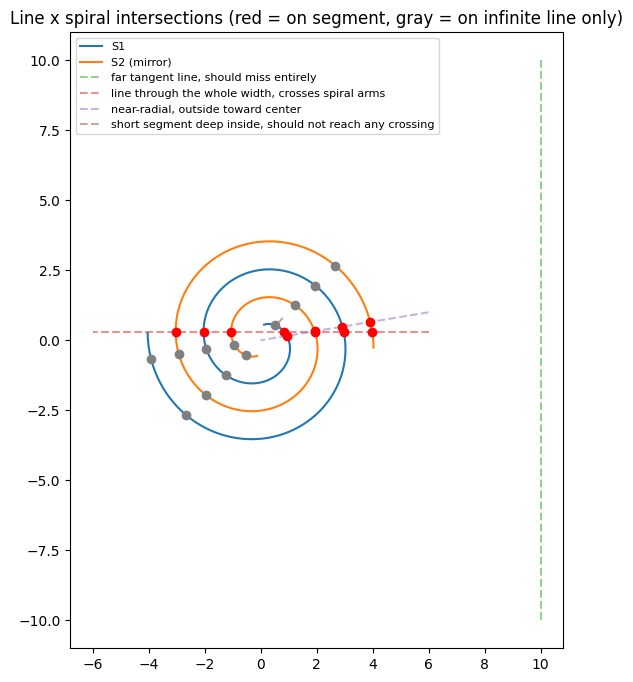

In [6]:
phis_plot = np.linspace(PHI0, PHI_MAX, 600)
s1 = np.array([spiral_xy(p) for p in phis_plot])
s2 = np.array([spiral_xy(p, mirror=True) for p in phis_plot])

plt.figure(figsize=(8, 8))
plt.plot(s1[:, 0], s1[:, 1], label='S1')
plt.plot(s2[:, 0], s2[:, 1], label='S2 (mirror)')

for label, p1, p2 in tests:
    p1, p2 = np.array(p1), np.array(p2)
    plt.plot([p1[0], p2[0]], [p1[1], p2[1]], '--', alpha=0.5, label=label)
    for mirror in (False, True):
        for r in find_spiral_line_intersections(p1, p2, mirror=mirror):
            pt = spiral_xy(r, mirror=mirror)
            t = segment_param(p1, p2, pt)
            color = 'red' if 0 <= t <= 1 else 'gray'
            plt.plot(*pt, 'o', color=color, markersize=6)

plt.gca().set_aspect('equal')
plt.legend(fontsize=8, loc='upper left')
plt.title('Line x spiral intersections (red = on segment, gray = on infinite line only)')
plt.show()